<a href="https://colab.research.google.com/github/2403a52271-pixel/NLP/blob/main/2403A52271_Ass_NLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

step 1_create a small corpus

In [1]:
d1 = "The cinematography was breathtaking and every scene looked beautifully crafted."
d2 = "The movie was boring and the storyline failed to keep my attention."
d3 = "The lead actors brought great energy that made the film enjoyable to watch."
d4 = "The script was weak and the characters felt unrealistic."
corpus = [d1,d2,d3,d4]
labels =["positive","negative","positve","negative"]
for i, (doc, label) in enumerate(zip(corpus, labels), start=1):
    print(f"d{i}: {doc} --> {label}")


d1: The cinematography was breathtaking and every scene looked beautifully crafted. --> positive
d2: The movie was boring and the storyline failed to keep my attention. --> negative
d3: The lead actors brought great energy that made the film enjoyable to watch. --> positve
d4: The script was weak and the characters felt unrealistic. --> negative


STEP 2 — Preprocess the corpus

In [3]:
import re
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))
def preprocess(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = [word for word in text.split() if word not in stop_words]
    return " ".join(tokens)
clean_corpus = [preprocess(doc) for doc in corpus]
for i, (original, cleaned) in enumerate(zip(corpus, clean_corpus), start=1):
    print(f"d{i} original: {original}")
    print(f"d{i} cleaned: {cleaned}\n")

d1 original: The cinematography was breathtaking and every scene looked beautifully crafted.
d1 cleaned: cinematography breathtaking every scene looked beautifully crafted

d2 original: The movie was boring and the storyline failed to keep my attention.
d2 cleaned: movie boring storyline failed keep attention

d3 original: The lead actors brought great energy that made the film enjoyable to watch.
d3 cleaned: lead actors brought great energy made film enjoyable watch

d4 original: The script was weak and the characters felt unrealistic.
d4 cleaned: script weak characters felt unrealistic



[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


STEP 3 — Feature Extraction with TF-IDF

In [4]:
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(clean_corpus)
y = labels
print("Vocabulary size:", len(vectorizer.vocabulary_))
print("Feature names:", list(vectorizer.vocabulary_.keys())[:10])
print("TF-IDF matrix shape:", X.shape)

Vocabulary size: 27
Feature names: ['cinematography', 'breathtaking', 'every', 'scene', 'looked', 'beautifully', 'crafted', 'movie', 'boring', 'storyline']
TF-IDF matrix shape: (4, 27)


STEP 4 — Train Logistic Regression Mode

In [5]:

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
log_reg = LogisticRegression(max_iter=200)
log_reg.fit(X, y)
y_pred = log_reg.predict(X)
print("Accuracy:", accuracy_score(y, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y, y_pred))

Accuracy: 1.0
Confusion Matrix:
 [[2 0 0]
 [0 1 0]
 [0 0 1]]


STEP 5 — Model Evaluation with Precision, Recall, F1

Accuracy: 1.0
Precision (weighted): 1.0
Recall (weighted): 1.0
F1-score (weighted): 1.0


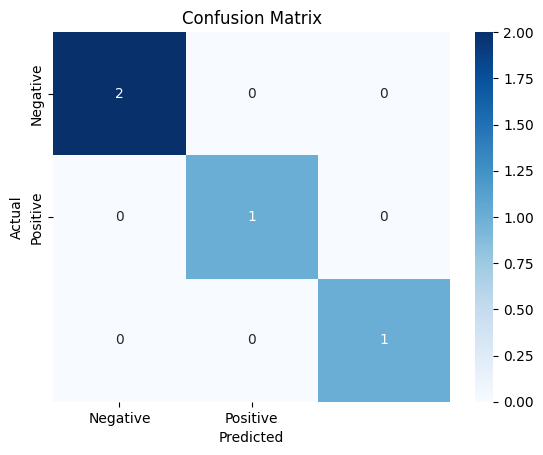

In [7]:
from sklearn.metrics import precision_score, recall_score, f1_score
print("Accuracy:", accuracy_score(y, y_pred))
print("Precision (weighted):", precision_score(y, y_pred, average='weighted'))
print("Recall (weighted):", recall_score(y, y_pred, average='weighted'))
print("F1-score (weighted):", f1_score(y, y_pred, average='weighted'))
import seaborn as sns
import matplotlib.pyplot as plt
cm = confusion_matrix(y, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative','Positive'],
            yticklabels=['Negative','Positive'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()